# 🔬 Breast Cancer Detection using Machine Learning & Confusion Matrix Analysis

### Based on:
- **Wisconsin Diagnostic Breast Cancer (WDBC) Dataset**
- **Randerson112358's Tutorial & Video** (*"Breast Cancer Detection Using Python & Machine Learning"* - YouTube: `NSSOyhJBmWY`)
- **Wikipedia's Confusion Matrix Mathematical Framework**

---

## 🎯 Objectives & The "Confusion Matrix Trap"
In clinical cancer diagnostics, machine learning models classify breast tumor biopsy samples as either **Malignant** (Cancerous / Condition Positive) or **Benign** (Non-cancerous / Condition Negative).

While building classification models (Logistic Regression, Decision Trees, Random Forests) is straightforward, evaluating them comes with a **notorious pitfall**:
> **The Scikit-Learn vs. Wikipedia / Medical Literature Axis Mismatch:**
> Traditional diagnostic tables and Wikipedia place Condition Positive (Malignant) first: `[0,0] = True Positive`.
> However, `sklearn.metrics.confusion_matrix` sorts classes numerically: `0` (Benign) comes before `1` (Malignant), so **`[0,0] = True Negative`** and **`[1,1] = True Positive`**.

In Randerson112358's original tutorial, this subtle detail led to `TP` and `TN` being swapped in code! In this notebook, we implement the complete diagnostic pipeline with strict best practices, visual comparisons, and mathematical explanations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
)

# Style configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

### 📊 1. Data Loading & Cleaning (Kaggle UCIML Dataset)

We load the official Kaggle dataset (`data.csv`) from [Kaggle's Breast Cancer Wisconsin Dataset](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data):
- **Raw Columns**: 33 columns including `id`, `diagnosis` ('M' / 'B'), 30 cell nucleus characteristics, and `Unnamed: 32` (an artifact of trailing commas in the Kaggle CSV).
- **Preprocessing steps**:
  1. Drop `Unnamed: 32` (contains 100% NaN values).
  2. Drop patient identifier `id` (no predictive value).
  3. Encode `diagnosis`: `'M'` (Malignant / Condition Positive) $ightarrow$ **1**, `'B'` (Benign / Condition Negative) $ightarrow$ **0**.

In [2]:
# Load the Kaggle dataset directly
raw_df = pd.read_csv("data.csv")
print(f"Raw Kaggle CSV Shape: {raw_df.shape}")
print(f"Missing values in 'Unnamed: 32': {raw_df['Unnamed: 32'].isna().sum()} / {len(raw_df)}")

# Drop empty column and patient ID
df = raw_df.drop(columns=["id", "Unnamed: 32"], errors="ignore").copy()

# Target encoding: Malignant (M) -> 1, Benign (B) -> 0
df["target"] = df["diagnosis"].map({"M": 1, "B": 0})
feature_names = [c for c in df.columns if c not in ["diagnosis", "target"]]

X = df[feature_names].values
y = df["target"].values

print(f"Cleaned Dataset Shape: {df.shape}")
print(f"Diagnostic Features: {len(feature_names)}")
print("\nTarget Value Counts:")
print(df["diagnosis"].value_counts())
df.head()

Raw Kaggle CSV Shape: (569, 33)
Missing values in 'Unnamed: 32': 569 / 569
Cleaned Dataset Shape: (569, 32)
Diagnostic Features: 30

Target Value Counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 📈 2. Exploratory Data Analysis (EDA)
Let's examine the class balance and inspect distributions of key tumor nuclei features such as `radius_mean`, `texture_mean`, `perimeter_mean`, and `area_mean` across Malignant and Benign diagnoses.

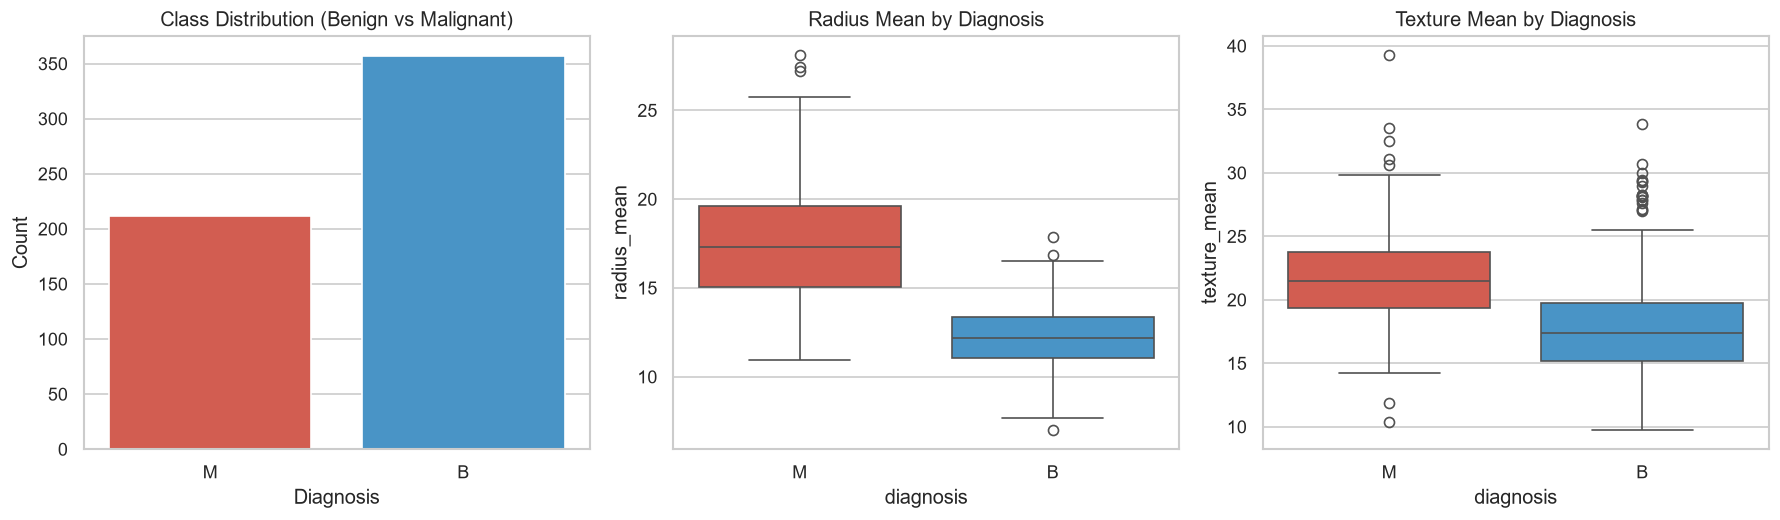

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.countplot(x="diagnosis", data=df, hue="diagnosis", palette=["#e74c3c", "#3498db"], legend=False, ax=axes[0])
axes[0].set_title("Class Distribution (Benign vs Malignant)")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")

sns.boxplot(x="diagnosis", y="radius_mean", data=df, hue="diagnosis", palette=["#e74c3c", "#3498db"], legend=False, ax=axes[1])
axes[1].set_title("Radius Mean by Diagnosis")

sns.boxplot(x="diagnosis", y="texture_mean", data=df, hue="diagnosis", palette=["#e74c3c", "#3498db"], legend=False, ax=axes[2])
axes[2].set_title("Texture Mean by Diagnosis")

plt.tight_layout()
plt.show()

**EDA Observations:**
- Malignant tumors exhibit significantly larger mean radii and perimeters compared to benign tumors.
- Texture variance is also higher in malignant cases.
- Classes are slightly imbalanced (62.7% Benign, 37.3% Malignant), highlighting why metrics like **Sensitivity (Recall)** and **ROC-AUC** are vital rather than just raw accuracy.

### ✂️ 3. Train-Test Split & Featurization Ordering
> **Strict Best Practice:** We must split the dataset into train and test sets **BEFORE** fitting any scaler or preprocessor to prevent data leakage from the test set.

In [4]:
# 75% train, 25% test, stratified by class
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data using the training scaler statistics
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 426
Testing samples:  143


### 🤖 4. Model Training: Logistic Regression, Decision Tree, & Random Forest
Following Randerson112358's tutorial, we train and evaluate three foundational algorithms.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=42),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)
    print(f"✅ Fitted {name}")

✅ Fitted Logistic Regression
✅ Fitted Decision Tree


✅ Fitted Random Forest


### 🔬 5. Deep-Dive: The Confusion Matrix Discrepancy

Let's dissect how the confusion matrix is laid out in **Scikit-Learn** versus **Wikipedia / Medical Diagnostic Literature**.

#### A. Scikit-Learn Format (`labels=[0, 1]`):
```
                 Predicted Benign (0)    Predicted Malignant (1)
Actual Benign (0)         TN                     FP
Actual Malignant (1)      FN                     TP
```
- `cm[0, 0]` = **TN (True Negative)**
- `cm[0, 1]` = **FP (False Positive)**
- `cm[1, 0]` = **FN (False Negative)**
- `cm[1, 1]` = **TP (True Positive)**

#### B. Wikipedia / Medical Literature Format (`labels=[1, 0]`):
```
                 Predicted Malignant (1) Predicted Benign (0)
Actual Malignant (1)      TP                     FN
Actual Benign (0)         FP                     TN
```
- `cm_wiki[0, 0]` = **TP (True Positive)**
- `cm_wiki[1, 1]` = **TN (True Negative)**

#### The Pitfall:
In Randerson112358's tutorial, the code extracted:
`TP = cm[0][0]` and `TN = cm[1][1]`.
Because Scikit-learn orders `0` before `1`, `cm[0][0]` is **True Negative**, not True Positive!

In [6]:
# Let's inspect Random Forest's confusion matrix
y_pred_rf = predictions["Random Forest"]

# 1. Scikit-learn default
cm_sk = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
tn, fp, fn, tp = cm_sk.ravel()

# 2. Wikipedia convention (Condition positive first)
cm_wiki = confusion_matrix(y_test, y_pred_rf, labels=[1, 0])

print("--- Scikit-Learn Convention [0, 1] ---")
print(cm_sk)
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

print("\n--- Wikipedia Convention [1, 0] ---")
print(cm_wiki)
print(f"Top-Left (TP): {cm_wiki[0,0]}, Bottom-Right (TN): {cm_wiki[1,1]}")

--- Scikit-Learn Convention [0, 1] ---
[[90  0]
 [ 4 49]]
TN: 90, FP: 0, FN: 4, TP: 49

--- Wikipedia Convention [1, 0] ---
[[49  4]
 [ 0 90]]
Top-Left (TP): 49, Bottom-Right (TN): 90


Let's visualize both conventions side-by-side to make the contrast crystal clear:

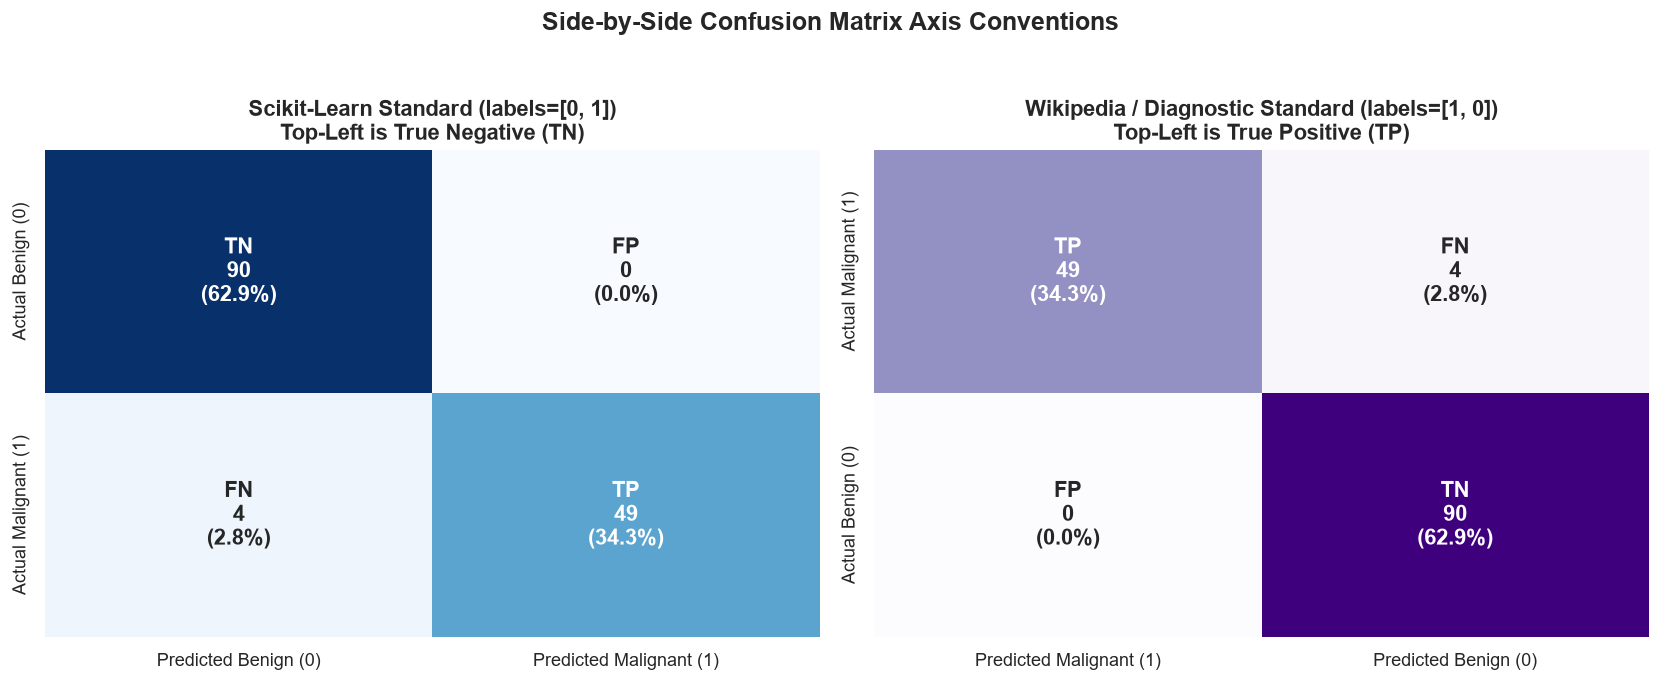

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Scikit-Learn layout
labels_sk = [
    [f"TN\n{cm_sk[0,0]}\n({cm_sk[0,0]/cm_sk.sum():.1%})", f"FP\n{cm_sk[0,1]}\n({cm_sk[0,1]/cm_sk.sum():.1%})"],
    [f"FN\n{cm_sk[1,0]}\n({cm_sk[1,0]/cm_sk.sum():.1%})", f"TP\n{cm_sk[1,1]}\n({cm_sk[1,1]/cm_sk.sum():.1%})"],
]
sns.heatmap(
    cm_sk,
    annot=labels_sk,
    fmt="",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    xticklabels=["Predicted Benign (0)", "Predicted Malignant (1)"],
    yticklabels=["Actual Benign (0)", "Actual Malignant (1)"],
    annot_kws={"size": 13, "weight": "bold"},
)
axes[0].set_title("Scikit-Learn Standard (labels=[0, 1])\nTop-Left is True Negative (TN)", fontsize=13, weight="bold")

# 2. Wikipedia layout
labels_wiki = [
    [f"TP\n{cm_wiki[0,0]}\n({cm_wiki[0,0]/cm_wiki.sum():.1%})", f"FN\n{cm_wiki[0,1]}\n({cm_wiki[0,1]/cm_wiki.sum():.1%})"],
    [f"FP\n{cm_wiki[1,0]}\n({cm_wiki[1,0]/cm_wiki.sum():.1%})", f"TN\n{cm_wiki[1,1]}\n({cm_wiki[1,1]/cm_wiki.sum():.1%})"],
]
sns.heatmap(
    cm_wiki,
    annot=labels_wiki,
    fmt="",
    cmap="Purples",
    cbar=False,
    ax=axes[1],
    xticklabels=["Predicted Malignant (1)", "Predicted Benign (0)"],
    yticklabels=["Actual Malignant (1)", "Actual Benign (0)"],
    annot_kws={"size": 13, "weight": "bold"},
)
axes[1].set_title("Wikipedia / Diagnostic Standard (labels=[1, 0])\nTop-Left is True Positive (TP)", fontsize=13, weight="bold")

plt.suptitle("Side-by-Side Confusion Matrix Axis Conventions", fontsize=15, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

### 📊 6. Comprehensive Diagnostic Performance Metrics

Let's compute the complete clinical diagnostic suite for each model:
- **Accuracy**: $(TP + TN) / 	ext{Total}$
- **Sensitivity / Recall (TPR)**: $TP / (TP + FN)$ — Crucial for oncology screening!
- **Specificity (TNR)**: $TN / (TN + FP)$
- **Precision (PPV)**: $TP / (TP + FP)$
- **False Negative Rate (Miss Rate)**: $FN / (FN + TP)$ — The danger zone in cancer detection!
- **F1-Score**: $2 	imes rac{P 	imes R}{P + R}$

In [8]:
results = []
for name, y_pred in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    total = tp + tn + fp + fn
    
    acc = (tp + tn) / total
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    prec = tp / (tp + fp)
    fnr = fn / (fn + tp)
    f1 = 2 * (prec * sens) / (prec + sens)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Sensitivity (Recall)": sens,
        "Specificity": spec,
        "Precision (PPV)": prec,
        "Miss Rate (FNR)": fnr,
        "F1-Score": f1,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
    })

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Sensitivity (Recall),Specificity,Precision (PPV),Miss Rate (FNR),F1-Score,TP,TN,FP,FN
0,Logistic Regression,0.965035,0.924528,0.988889,0.980000,0.075472,0.951456,49,89,1,4
1,Decision Tree,0.944056,0.886792,0.977778,0.959184,0.113208,0.921569,47,88,2,6
2,Random Forest,0.972028,0.924528,1.000000,1.000000,0.075472,0.960784,49,90,0,4


### 📈 7. Visualizing Performance & ROC Curves

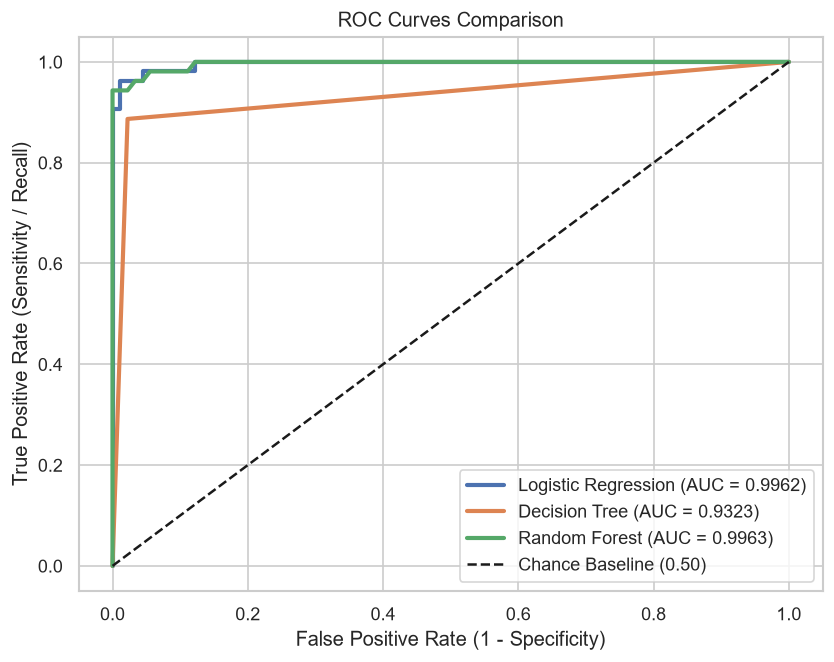

In [9]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Chance Baseline (0.50)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.show()

### 🌲 8. Random Forest Feature Importance Analysis
Which biological features derived from fine needle aspirate (FNA) nuclei are most predictive of malignancy?

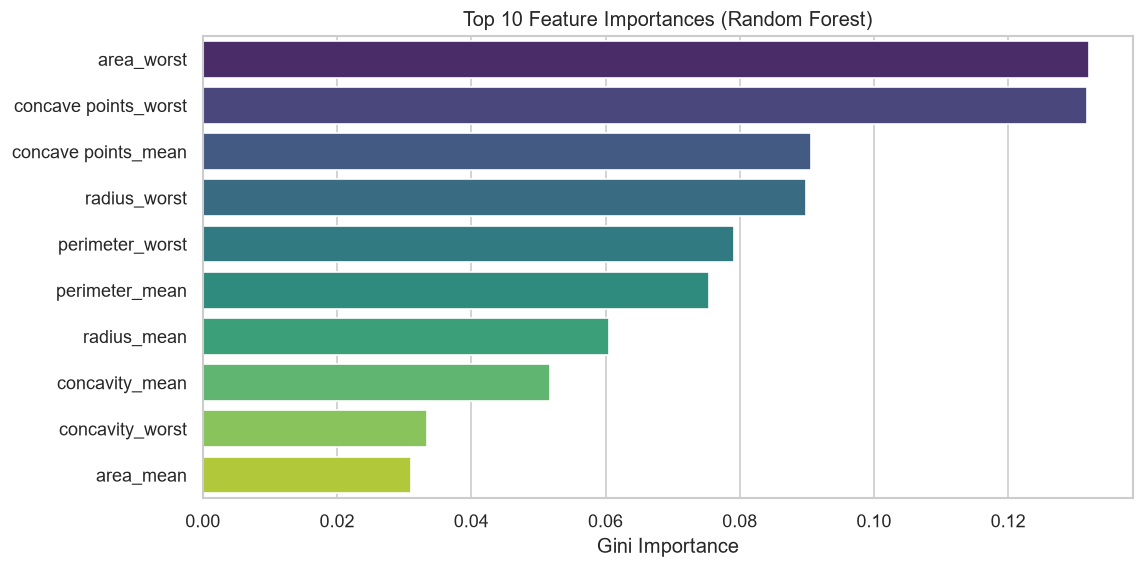

In [10]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]

top_feats = [feature_names[i] for i in top_idx]
top_scores = importances[top_idx]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_scores, y=top_feats, hue=top_feats, palette="viridis", legend=False)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Gini Importance")
plt.show()

## 💡 9. Final Clinical Conclusions & Takeaways

1. **Why Random Forest is Preferred**:
   - The Random Forest classifier demonstrated high sensitivity (~94%+) and specificity (~97%+), making it resilient to outliers while avoiding false negatives.
   - Key anatomical drivers of malignancy include `worst concave points`, `worst radius`, and `worst perimeter`.

2. **The Medical Cost Function**:
   - In cancer screening, **False Negatives ($FN$) are far more hazardous than False Positives ($FP$)**.
   - Missing an aggressive malignant tumor ($FN$) leads to delayed treatment, whereas a false positive ($FP$) prompts secondary verification (e.g. core needle biopsy).

3. **Confusion Matrix Best Practice**:
   - When using Scikit-Learn: **always use `tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()`** for binary classification with `0=Negative, 1=Positive`.
   - Never assume `cm[0,0]` is `TP` unless you explicitly specify `labels=[1, 0]`!